# Time Series Analysis – US Alcohol Retail Sales

## Dataset

Il dataset **Retail Sales of Beer, Wine, and Liquor Stores** è disponibile pubblicamente tramite il database [FRED](https://fred.stlouisfed.org/series/S4248SM144NCEN) (Federal Reserve Economic Data) della Federal Reserve Bank di St. Louis.

Contiene le vendite mensili al dettaglio di negozi di alcolici negli Stati Uniti, espresse in milioni di dollari, a partire dal gennaio 1992.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('S4248SM144NCEN.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'], format='%Y-%m-%d')
df = df.rename(columns={'observation_date': 'Date', 'S4248SM144NCEN': 'sales'})

print(f'Periodo: {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Osservazioni: {len(df)}')
df.head(13)

Periodo: 1992-01-01 → 2026-02-01
Osservazioni: 410


,Date,sales
0,1992-01-01,3459
1,1992-02-01,3458
2,1992-03-01,4002
3,1992-04-01,4564
4,1992-05-01,4221
5,1992-06-01,4529
6,1992-07-01,4466
7,1992-08-01,4137
8,1992-09-01,4126
9,1992-10-01,4259


In [38]:
df.isna().sum()

Date     0
sales    0
dtype: int64

Il dataset non presenta missing values per cui non abbiamo bisogno di metodi come l'interpolazione.

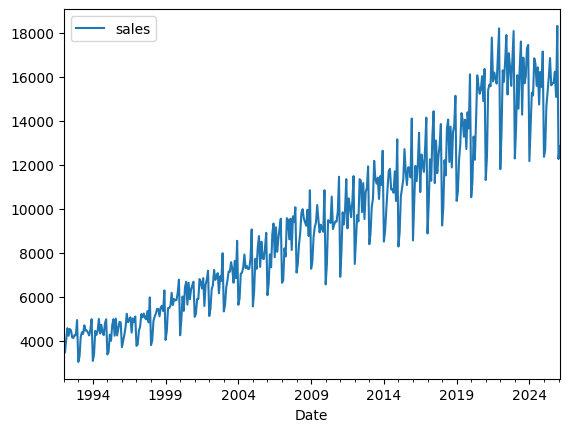

In [39]:
df.plot(x='Date', y='sales')
plt.show()

## Smoothing

La time series ha una chiara stagionalità basata sui mesi, (con picco a dicembre e crollo consecutivo a gennaio), motivo per cui uso per smoothing una centered rolling window di lunghezza 12 per visualizzare meglio il trend rimuovendo l'effetto appunto della stagionalità.

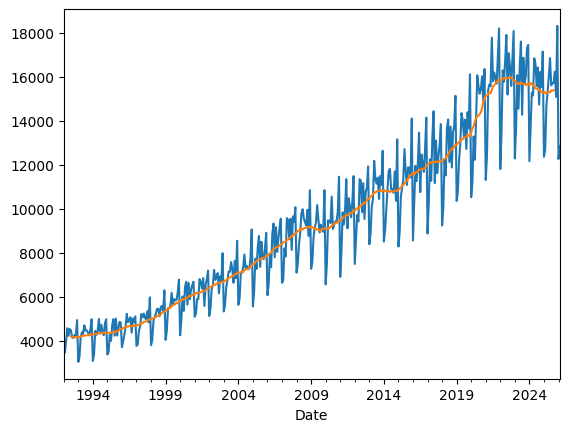

In [40]:
df0 = df.copy()
df0.set_index('Date', inplace=True)
df0['sales'].plot()
df0['sales'].rolling(12, center=True).mean().plot()
plt.show()

Il patter della time series è quindi:   (senza considerare gli ultimi circa 5 anni)
- trend moltiplicativo
- stagionalità moltiplicativa  (la sua ampiezza aumenta sempre di più)

### Regressive Model

Come consigliato durante la lezione, non eseguirò questa parte perchè abbiamo dimostrato che i modelli regressivi effettuano degli errori di predizione (residui) che mostrano essere autocorrelati.

Questo significa che l'errore non è rumore, ma contiene dei pattern che non sono stati catturati dal modello, motivo per cui procedo alla trattazione di modelli autoregressivi che mitigano questo problema.

# Autoregressive Model

Il primo passo per poter utilizzare un modello autoregressivo è quello di ottenere una serie stazionaria, abbiamo visto le 3 condizioni di stazionarietà debole e come ottenerle attraverso vari metodi.

Avendo un trend e stagionalità moltiplicativa:
- regolo l'aumento della varianza nel tempo "noise" attraverso una box-cox. (equivalente era la log)
- rimuovo stagionalità con diff12 
- rimuovo trend con diff2

Visualizzo la correlazione della TS prima di applicare qualsiasi trasformazione.

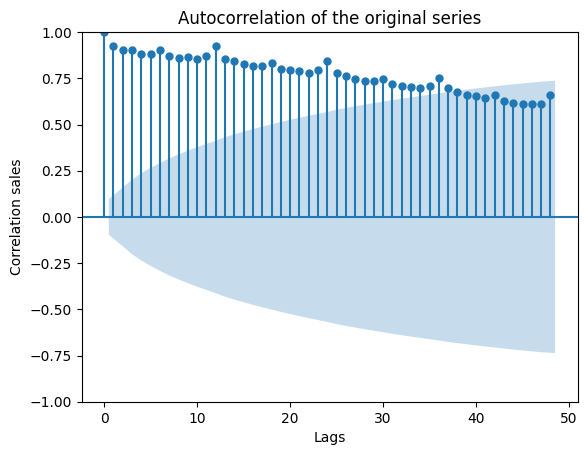

In [42]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df0['sales'].dropna(), lags=48)
plt.ylabel('Correlation sales')
plt.xlabel('Lags')
plt.title('Autocorrelation of the original series')
plt.show()

Applico trasformazione box-cox per rimuovere la stagionalità moltiplicativa

Lambda Box-Cox stimato: 0.2561
(lambda vicino a 0 indica che la trasformazione logaritmica è appropriata)


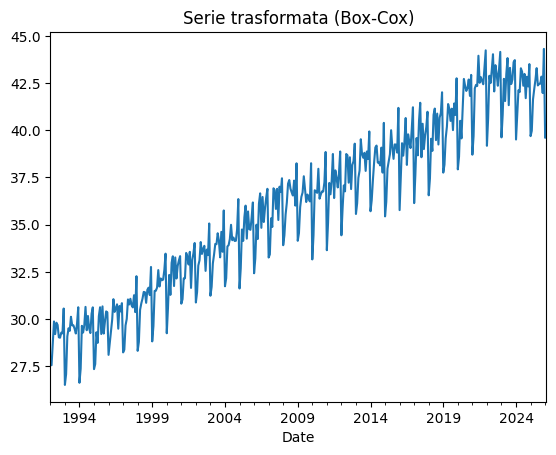

In [43]:
from scipy.stats import boxcox

df0 = df.copy()
df0.set_index('Date', inplace=True)

df0['sales_bc'], lambda_bc = boxcox(df0['sales'])

print(f'Lambda Box-Cox stimato: {lambda_bc:.4f}')
print('(lambda vicino a 0 indica che la trasformazione logaritmica è appropriata)')

df0['sales_bc'].plot()
plt.title('Serie trasformata (Box-Cox)')
plt.show()

Rimuovo  stagionalità (diff-12) e successivamente trend (diff-2).

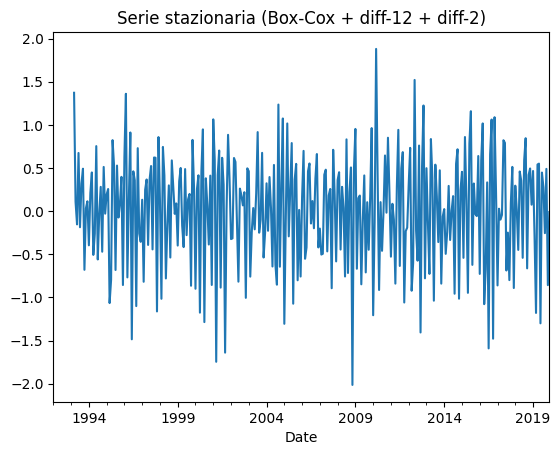

In [152]:
df0['sales_bc_diff12'] = df0['sales_bc'].diff(12)        # rimuove stagionalità
df0['sales_bc_stationary'] = df0['sales_bc_diff12'].diff(2)  # rimuove trend

df0['sales_bc_stationary'].plot()
plt.title('Serie stazionaria (Box-Cox + diff-12 + diff-2)')
plt.show()

Testo che la TS ottenuta sia effettivamente stazionaria

In [153]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    """Using an ADF test to determine if a series is stationary"""
    test_results = adfuller(series)
    print('ADF Statistic: ', test_results[0])
    print('P-Value: ', test_results[1])
    print('Critical Values:')
    for thres, adf_stat in test_results[4].items():
        print('\t%s: %.2f' % (thres, adf_stat))

adf_test(df0['sales_bc_stationary'].dropna())

ADF Statistic:  -5.766118352887726
P-Value:  5.527696767602955e-07
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57


La serie è quindi stazionaria (p-value molto basso) per cui possiamo passare all'analisi del plot di autocorrelazione:

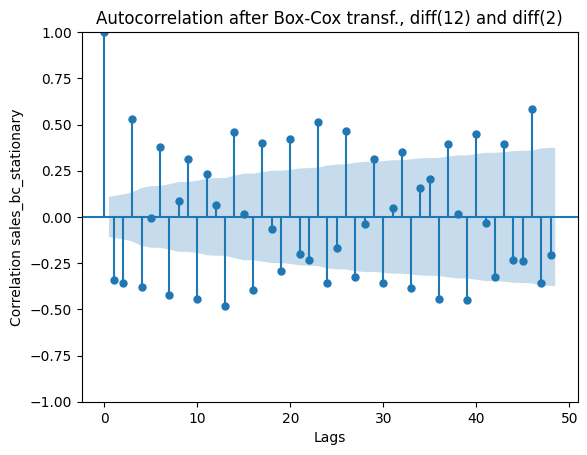

       lb_stat     lb_pvalue
1    37.421690  9.515798e-10
2    79.038411  6.871113e-18
3   171.493124  6.057805e-37
4   218.411557  4.118483e-46
5   218.427178  3.227534e-45
6   265.690728  1.812143e-54
7   325.172088  2.526959e-66
8   327.757648  5.031791e-66
9   360.665985  3.322456e-72
10  426.256430  2.410649e-85


In [154]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plot_acf(df0['sales_bc_stationary'].dropna(), lags=48)
plt.ylabel('Correlation sales_bc_stationary')
plt.xlabel('Lags')
plt.title('Autocorrelation after Box-Cox transf., diff(12) and diff(2)')
plt.show()

print(acorr_ljungbox(df0['sales_bc_stationary'].dropna(), return_df=True))

Come visto a lezione la serie ottenuta è stazionaria ma presenta comunque della correlazione, non è white-noise, e questo viene mostrato numericamente tramite il test di ljung (oltre che il grafico).

## Modello AR(p)

Provo come prima cosa a fittare un modello auto-regressivo andando a scegliere "p" a mano dal grafico di autocorrelazione parziale

Let us inspect the PACF behavior to choose AR order p


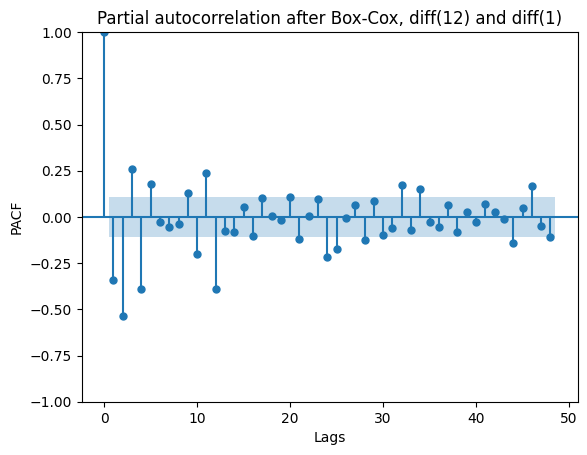

In [155]:
from statsmodels.graphics.tsaplots import plot_pacf

print("Let us inspect the PACF behavior to choose AR order p")
plot_pacf(df0['sales_bc_stationary'].dropna(), lags=48)
plt.ylabel('PACF')
plt.xlabel('Lags')
plt.title('Partial autocorrelation after Box-Cox, diff(12) and diff(1)')
plt.show()

Split train e test --> per ragioni predittive ho eliminato gli ultimi 5 anni che mostrano un trend diverso (in leggera decrescita)

Fit con lag deciso guardando il grafico

In [168]:
from statsmodels.tsa.ar_model import AutoReg
from scipy.special import inv_boxcox

# Taglio al 2019 per escludere l'anomalia Covid
df0 = df0[:'2019']
df0 = df0.asfreq('MS')

# Colonna stazionaria
df0['stationary'] = df0['sales_bc'].diff(12).diff()

print("Split the data into train and test sets")
train = df0.iloc[:-24]
test  = df0.iloc[-24:]


# Fit AR
model = AutoReg(
    train['stationary'].dropna(),
    lags=5    #  guardando il grafico della PACF     (alternativa 12)
).fit()

Split the data into train and test sets


Inferenza e inversione delle trasformazioni per visualizzare la predizione.

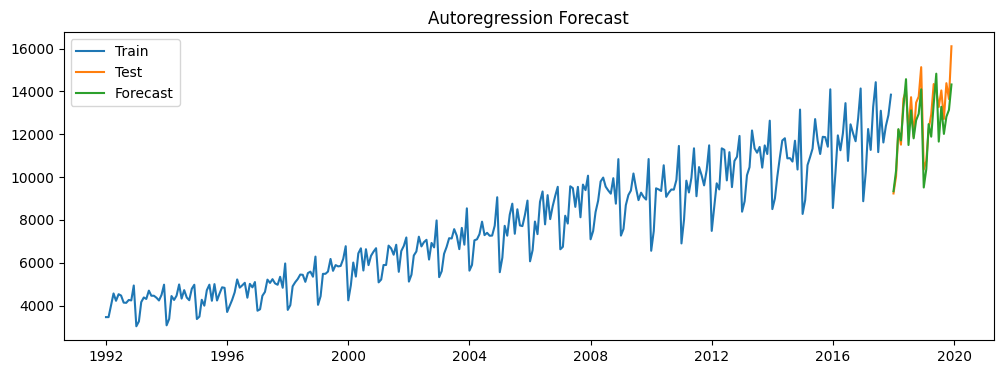

Mean absolute percentage error: 0.0516


In [157]:
# Forecast nel dominio differenziato
diff_forecasts = list(model.forecast(steps=len(test)))

# Inverti diff(1)
seasonal_diff_forecasts = []
last_seasonal_diff = train['sales_bc'].diff(12).iloc[-1]
for i, f in enumerate(diff_forecasts):
    if i == 0:
        val = f + last_seasonal_diff
    else:
        val = f + seasonal_diff_forecasts[i-1]
    seasonal_diff_forecasts.append(val)

# Inverti diff(12)
bc_forecasts = []
for i, f in enumerate(seasonal_diff_forecasts):
    if i < 12:
        val = f + train['sales_bc'].iloc[-(12-i)]
    else:
        val = f + bc_forecasts[i-12]
    bc_forecasts.append(val)

# Inverti Box-Cox
forecasts = inv_boxcox(bc_forecasts, lambda_bc)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(train.index, inv_boxcox(train['sales_bc'], lambda_bc), label='Train')
plt.plot(test.index,  inv_boxcox(test['sales_bc'],  lambda_bc), label='Test')
plt.plot(test.index,  forecasts, label='Forecast')
plt.title('Autoregression Forecast')
plt.legend()
plt.show()

mean_abs_err = (np.abs(forecasts - inv_boxcox(test['sales_bc'], lambda_bc)) /
                inv_boxcox(test['sales_bc'], lambda_bc)).mean()
print(f'Mean absolute percentage error: {mean_abs_err:.4f}')

La predizione sembra ragionevolmente buona ma controlliamo la correlazione tra i residui del modello per vedere se effettivamente è rimasto solo "rumore".

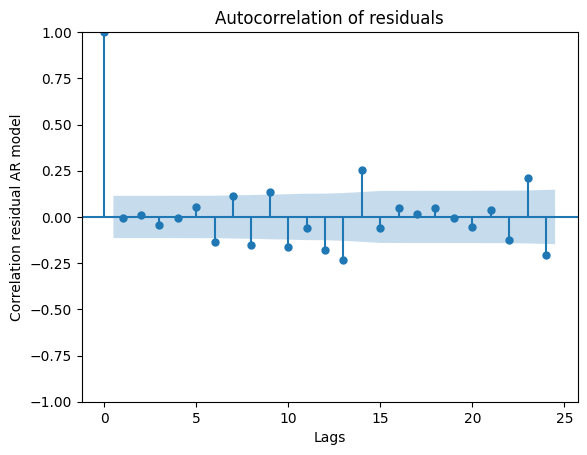

      lb_stat  lb_pvalue
1    0.005718   0.939723
2    0.036795   0.981771
3    0.554968   0.906660
4    0.576695   0.965618
5    1.483146   0.915007
6    7.089561   0.312644
7   11.038728   0.136939
8   18.061443   0.020771
9   23.543158   0.005085
10  31.750193   0.000441


In [158]:
residuals = model.resid.dropna()

plot_acf(residuals, lags=24)
plt.ylabel('Correlation residual AR model')
plt.xlabel('Lags')
plt.title('Autocorrelation of residuals')
plt.show()

print(acorr_ljungbox(residuals, return_df=True))

Il grafico e i valori suggeriscono che il modello AR(p) non ha prodotto dei residui completamente scorrelati, presentando quindi il medesimo limite dei modelli regressivi, il notebook visto a lezione suggerisce che il problema sta nel come viene gestita la stagionalità ed infatti usando AR(12) si ottengono residui altamente meno correlati ma ad un rischio di overfitting visto il modello con 12 parametri per un dataset relativamente piccolo.

DI conseguenza provo ad utilizzare ARIMA direttamente sul modello originale linearizzato.

## ARIMA

D'apprima scelgo la p e q tramite i grafici ACF e PACF.

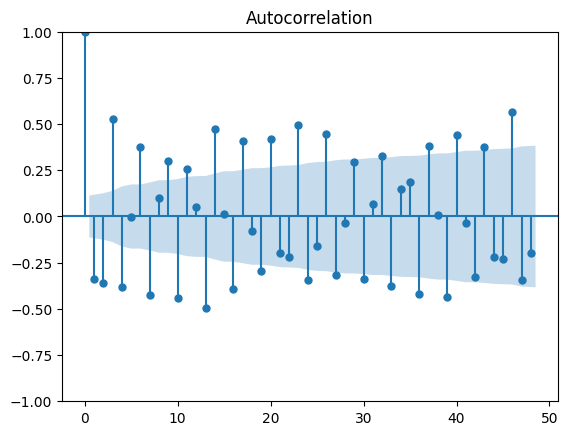

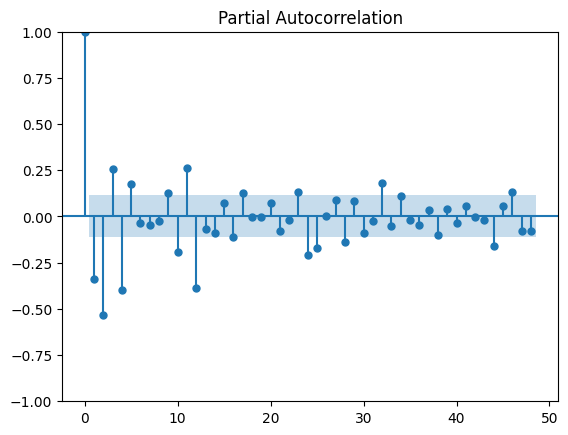

In [159]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

stationary_train = df0['sales_bc_stationary'].loc[train.index].dropna()

plot_acf(stationary_train, lags=48)
plt.show()

plot_pacf(stationary_train, lags=48)
plt.show()

I grafici non risultano essere "puliti" come quelli visti a lezione, probabilmente è causato dall'utilizzo di una time series più complessa.

Visualizzandoli sembra ragionevole:
- p=3 
- q=1

Linearizzo il modello usando una log transformation (potevo utilizzare la box-cox già usata in precedenza).

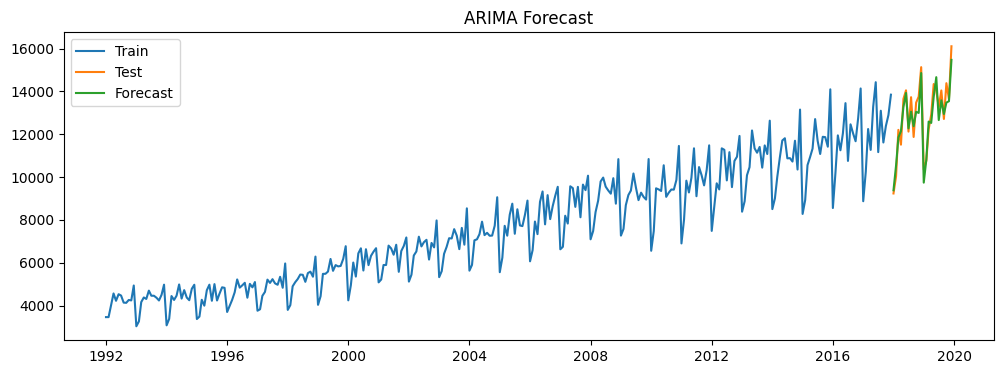

Mean absolute error: 0.0339


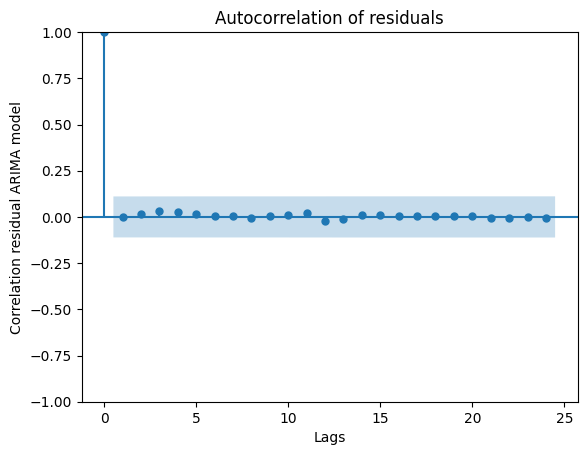

     lb_stat  lb_pvalue
1   0.000198   0.988764
2   0.089485   0.956243
3   0.420667   0.935941
4   0.611076   0.961825
5   0.682226   0.983930
6   0.691021   0.994683
7   0.702567   0.998316
8   0.723062   0.999466
9   0.730164   0.999848
10  0.778448   0.999946


In [167]:
from statsmodels.tsa.arima.model import ARIMA

df0['sales_log'] = np.log(df0['sales'])
df0 = df0[:'2019']

train = df0.iloc[:-24]  
test  = df0.iloc[-24:]

model = ARIMA(
    train['sales_log'],
    order=(3, 1, 1),    # (p, d, q) aka (AR, diff, MA)
    seasonal_order=(1, 0, 1, 12)    # (P, D, Q, m) aka (AR stag., diff stag., MA stag., periodicità)
).fit()

# Forecast nel dominio log
log_forecasts = model.forecast(steps=len(test))

# Inverti log
forecasts = np.exp(log_forecasts)

# Plot
plt.figure(figsize=(12, 4))
plt.plot(train.index, np.exp(train['sales_log']), label='Train')
plt.plot(test.index,  np.exp(test['sales_log']),  label='Test')
plt.plot(test.index,  forecasts, label='Forecast')
plt.title('ARIMA Forecast')
plt.legend()
plt.show()

mean_abs_err = (np.abs(forecasts - np.exp(test['sales_log'])) /
                np.exp(test['sales_log'])).mean()
print(f'Mean absolute error: {mean_abs_err:.4f}')

# Residui
residuals = model.resid.dropna()
plot_acf(residuals, lags=24)
plt.ylabel('Correlation residual ARIMA model')
plt.xlabel('Lags')
plt.title('Autocorrelation of residuals')
plt.show()

print(acorr_ljungbox(residuals, return_df=True))

In conclusione l'inferenza del modello ARIMA risulta essere:
- visivamente migliore rispetto al modello AR(p), e in generale decisamente precisa con un MAE di 0.03
- la correlazione dei residui è praticamente nulla, quindi il modello è riuscito a catturare tutti i pattern della TS superando appunto i limiti del modello AR

Solo per completezza implemento il modello lineare mostrando che i residui sono autocorrelati, quindi  mostrandone il limite.

Prima di tutto essendo la TS stagionale aggiungo 12 dummy variable per modellarle. 

In [173]:
import statsmodels.api as sm

# Dummy variabili mensilih
df0 = df0.reset_index()  # riporta Date da index a colonna
df0['Month_no'] = df0['Date'].dt.month
month_vars = pd.get_dummies(df0['Month_no'], drop_first=True, prefix='m').astype(int)

# Dataset per regressione
df_regr = pd.concat([df0, month_vars], axis=1)

# Variabile temporale: numero di mesi dal primo osservazione
df_regr['time'] = range(len(df_regr))

df_regr.head()

,Date,sales,sales_bc,sales_bc_diff12,sales_bc_stationary,stationary,sales_log,Month_no,m_2,m_3,m_4,m_5,m_6,m_7,m_8,m_9,m_10,m_11,m_12,time
0,1992-01-01,3459,27.559337,NaN,NaN,NaN,8.148735,1,0,0,0,0,0,0,0,0,0,0,0,0
1,1992-02-01,3458,27.557008,NaN,NaN,NaN,8.148446,2,1,0,0,0,0,0,0,0,0,0,0,1
2,1992-03-01,4002,28.756313,NaN,NaN,NaN,8.294550,3,0,1,0,0,0,0,0,0,0,0,0,2
3,1992-04-01,4564,29.873962,NaN,NaN,NaN,8.425955,4,0,0,1,0,0,0,0,0,0,0,0,3
4,1992-05-01,4221,29.204933,NaN,NaN,NaN,8.347827,5,0,0,0,1,0,0,0,0,0,0,0,4


Splitto train, test e fitto il modello

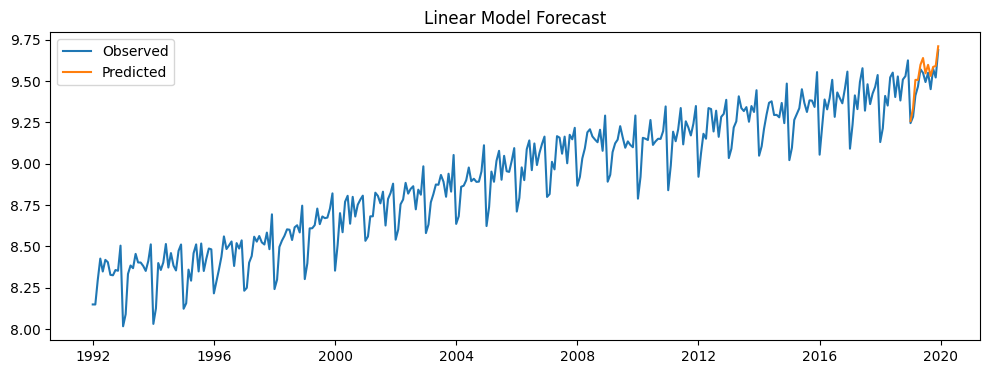

,Odds Ratio,5%,95%,t-value,p-value
const,8.029935,8.005767,8.054103,653.745947,0.000000e+00
time,0.003790,0.003723,0.003857,110.893477,4.289528e-252
m_2,0.074466,0.043675,0.105258,4.758500,2.991425e-06
m_3,0.241243,0.210451,0.272035,15.415694,3.160027e-40
m_4,0.237416,0.206624,0.268208,15.170934,2.700509e-39
m_5,0.324944,0.294151,0.355736,20.763657,1.088434e-60
m_6,0.362152,0.331359,0.392945,23.140740,1.357008e-69
m_7,0.265716,0.234922,0.296510,16.978251,3.292986e-46
m_8,0.313321,0.282526,0.344116,20.019430,7.304054e-58
m_9,0.242547,0.211751,0.273343,15.496793,1.550737e-40


In [ ]:
features = ['time', 'm_2', 'm_3', 'm_4', 'm_5', 'm_6', 'm_7', 'm_8', 'm_9', 'm_10', 'm_11', 'm_12']

Y_train = df_regr['sales_log'].iloc[:-12]
X_train = df_regr[features].iloc[:-12]
X_train = sm.add_constant(X_train)

Y_test = df_regr['sales_log'].iloc[-12:]
X_test = df_regr[features].iloc[-12:]
X_test = sm.add_constant(X_test)

# Fit modello lineare
model_ols = sm.OLS(Y_train, X_train)
results = model_ols.fit()
predictions = results.predict(X_test)

plt.figure(figsize=(12, 4))
plt.plot(df_regr['Date'], df_regr['sales_log'], label='Observed')
plt.plot(df_regr['Date'].iloc[-12:], predictions, label='Predicted')
plt.title('Linear Model Forecast')
plt.legend()
plt.show()

conf = results.conf_int()
params = np.reshape(results.params, (results.params.size, 1))
tvalues = np.reshape(results.tvalues, (results.tvalues.size, 1))
pvalues = np.reshape(results.pvalues, (results.pvalues.size, 1))
res_df = pd.DataFrame(np.concatenate((params, conf, tvalues, pvalues), axis=1))
res_df.columns = ['Odds Ratio', '5%', '95%', 't-value', 'p-value']
res_df.index = ['const'] + features
res_df

Finalmente, osservo i residui e la loro autocorrelazione

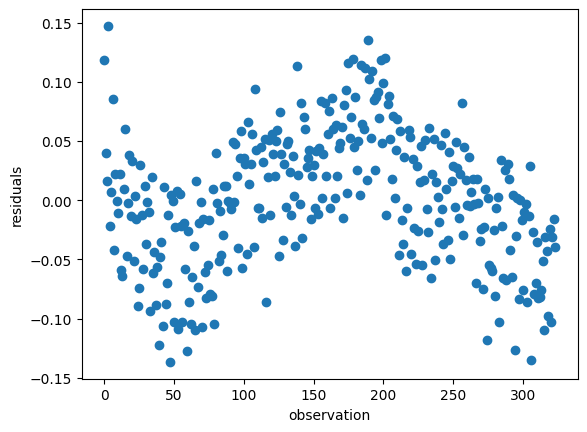

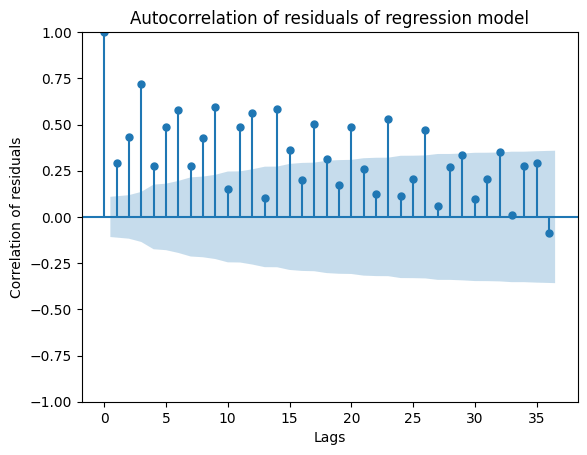

ADF Statistic:  -1.2232547093603905
P-Value:  0.6635129883075295
Critical Values:
	1%: -3.45
	5%: -2.87
	10%: -2.57



       lb_stat      lb_pvalue
1    27.690484   1.423613e-07
2    89.681945   3.355932e-20
3   259.586349   5.524399e-56
4   284.324393   2.603579e-60
5   362.085452   4.372922e-76
6   472.872436   5.849608e-99
7   498.587790  1.612870e-103
8   559.173750  1.390050e-115
9   677.130563  5.696003e-140
10  684.843102  1.125462e-140


In [177]:
from statsmodels.graphics.tsaplots import plot_acf

residuals = Y_train - results.predict(X_train)
plt.scatter(X_train['time'], residuals)
plt.ylabel('residuals')
plt.xlabel('observation')
plt.show()

plot_acf(residuals, lags=36)
plt.ylabel('Correlation of residuals')
plt.xlabel('Lags')
plt.title('Autocorrelation of residuals of regression model')
plt.show()


adf_test(results.predict(X_train) - Y_train)
print('\n\n')

print(acorr_ljungbox(results.predict(X_train) - Y_train, return_df=True))


Come ci si aspettava i residui non sono semplice rumore, lo si vede sia graficamente che tramite il test Ljung, mostrando quanto detto in precedenza e motivando l'uso di ARIMA come predittore.